In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Load the data - using the path we verified earlier
ncaa = pd.read_csv('Data/ncaa_data.csv')

# Clean the column names (fixing that hidden space in 'Class ')
ncaa.columns = ncaa.columns.str.strip()

# Fill missing 3P% with 0
ncaa['3P%'] = ncaa['3P%'].fillna(0)

ncaa.head()

,Player,Season,Team,GP,GS,MP,FG,FGA,2P,2PA,...,PTS,FG%,2P%,3P%,FT%,TS%,eFG%,POS,Class,Drafted
0,James Bouknight,2020-21,Connecticut,15,14,475,98,219,76,144,...,281,0.447,0.528,0.293,0.778,0.546,0.498,G,SO,1
1,Caris LeVert,2015-16,Michigan,15,14,464,82,162,53,97,...,247,0.506,0.546,0.446,0.794,0.636,0.596,G,SR,1
2,B.J. Taylor,2017-18,UCF,16,14,495,80,201,54,134,...,254,0.398,0.403,0.388,0.673,0.510,0.463,G,JR,0
3,Emanuel Miller,2020-21,Texas A&M,17,13,538,100,175,100,169,...,276,0.571,0.592,0.000,0.817,0.630,0.571,F,SO,0
4,Dylan Disu,2020-21,Vanderbilt,17,17,537,89,181,65,116,...,255,0.492,0.560,0.369,0.736,0.592,0.558,F,SO,0


In [4]:
# Create Per Game Metrics
ncaa['PPG'] = ncaa['PTS'] / ncaa['GP']
ncaa['RPG'] = ncaa['TRB'] / ncaa['GP']
ncaa['APG'] = ncaa['AST'] / ncaa['GP']
ncaa['SPG'] = ncaa['STL'] / ncaa['GP']
ncaa['BPG'] = ncaa['BLK'] / ncaa['GP']

# Task 1: Calculate Draft Percentage
draft_pct = ncaa['Drafted'].mean() * 100
print(f"Percentage of players drafted: {draft_pct:.2f}%")

Percentage of players drafted: 9.87%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
ncaa = pd.read_csv('Data/ncaa_data.csv')

# 2. Clean the column names (removes hidden spaces like 'Class ')
ncaa.columns = ncaa.columns.str.strip()

# 3. Fill missing 3-point percentages with 0
ncaa['3P%'] = ncaa['3P%'].fillna(0)

# Verify loading
ncaa.head()

,Player,Season,Team,GP,GS,MP,FG,FGA,2P,2PA,...,PTS,FG%,2P%,3P%,FT%,TS%,eFG%,POS,Class,Drafted
0,James Bouknight,2020-21,Connecticut,15,14,475,98,219,76,144,...,281,0.447,0.528,0.293,0.778,0.546,0.498,G,SO,1
1,Caris LeVert,2015-16,Michigan,15,14,464,82,162,53,97,...,247,0.506,0.546,0.446,0.794,0.636,0.596,G,SR,1
2,B.J. Taylor,2017-18,UCF,16,14,495,80,201,54,134,...,254,0.398,0.403,0.388,0.673,0.510,0.463,G,JR,0
3,Emanuel Miller,2020-21,Texas A&M,17,13,538,100,175,100,169,...,276,0.571,0.592,0.000,0.817,0.630,0.571,F,SO,0
4,Dylan Disu,2020-21,Vanderbilt,17,17,537,89,181,65,116,...,255,0.492,0.560,0.369,0.736,0.592,0.558,F,SO,0


In [6]:
# Task 1: Percentage of players drafted
draft_pct = ncaa['Drafted'].mean() * 100
print(f"Task 1: {draft_pct:.2f}% of players were drafted.")

# Task 2: Top 5 Schools by drafted players
drafted_only = ncaa[ncaa['Drafted'] == 1]
top_schools = drafted_only['Team'].value_counts().head(5)
print("\nTask 2: Top 5 Schools:")
print(top_schools)

# Task 3: Draft rate by Position
pos_rate = ncaa.groupby('POS')['Drafted'].mean().sort_values(ascending=False)
print("\nTask 3: Draft Rate by Position:")
print(pos_rate * 100)

Task 1: 9.87% of players were drafted.

Task 2: Top 5 Schools:
Team
Kentucky    22
Duke        21
Gonzaga     11
UCLA        11
Michigan    10
Name: count, dtype: int64

Task 3: Draft Rate by Position:
POS
F    11.619718
C    11.184211
G     8.778055
Name: Drafted, dtype: float64


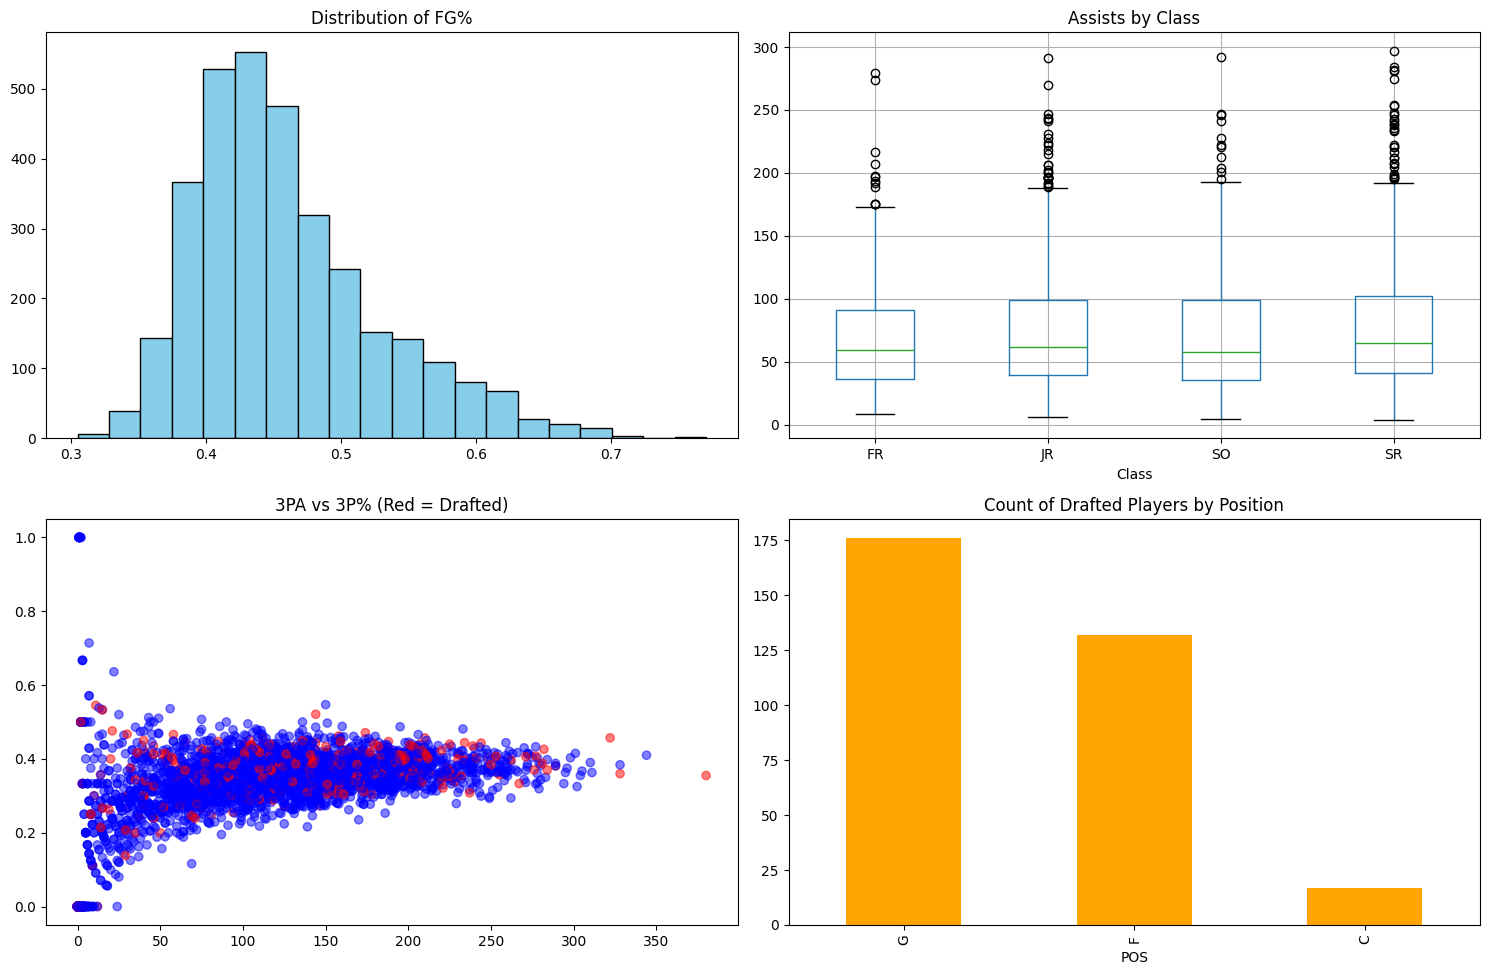

In [7]:
plt.figure(figsize=(15, 10))

# 1. Distribution of FG%
plt.subplot(2, 2, 1)
plt.hist(ncaa['FG%'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of FG%')

# 2. Boxplot of AST by Class (Using the cleaned 'Class' name)
plt.subplot(2, 2, 2)
ncaa.boxplot(column='AST', by='Class', ax=plt.gca())
plt.title('Assists by Class')
plt.suptitle('') 

# 3. Scatter: 3PA vs 3P%
plt.subplot(2, 2, 3)
colors = {1: 'red', 0: 'blue'}
plt.scatter(ncaa['3PA'], ncaa['3P%'], c=ncaa['Drafted'].map(colors), alpha=0.5)
plt.title('3PA vs 3P% (Red = Drafted)')

# 4. Bar: Count of Drafted Players by Position
plt.subplot(2, 2, 4)
ncaa[ncaa['Drafted'] == 1]['POS'].value_counts().plot(kind='bar', color='orange')
plt.title('Count of Drafted Players by Position')

plt.tight_layout()
plt.show()

In [8]:
# 1. Create Per Game Stats (Normalization)
ncaa['PPG'] = ncaa['PTS'] / ncaa['GP']
ncaa['RPG'] = ncaa['TRB'] / ncaa['GP']
ncaa['APG'] = ncaa['AST'] / ncaa['GP']
ncaa['SPG'] = ncaa['STL'] / ncaa['GP']
ncaa['BPG'] = ncaa['BLK'] / ncaa['GP']
ncaa['TOPG'] = ncaa['TOV'] / ncaa['GP']

# 2. Select our Features (X) and our Target (y)
# We use stats that are most likely to influence a scout's decision
features = ['PPG', 'RPG', 'APG', 'SPG', 'BPG', 'TOPG', 'FG%', '3P%', 'FT%']
X = ncaa[features]
y = ncaa['Drafted']

print("Features Prepared:", features)

Features Prepared: ['PPG', 'RPG', 'APG', 'SPG', 'BPG', 'TOPG', 'FG%', '3P%', 'FT%']


In [9]:
from sklearn.model_selection import train_test_split

# Split: 80% to train, 20% to test
# random_state=42 ensures you get the same results every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} players.")
print(f"Testing on {len(X_test)} players.")

Training on 2634 players.
Testing on 659 players.


In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Model
# We use 'scale_pos_weight' because there are way more non-drafted players than drafted ones
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)

# 2. Train (Fit) the model
model.fit(X_train, y_train)

# 3. Make predictions on the test set
predictions = model.predict(X_test)

# 4. Check the Results
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 89.38%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       588
           1       0.53      0.14      0.22        71

    accuracy                           0.89       659
   macro avg       0.72      0.56      0.58       659
weighted avg       0.86      0.89      0.87       659



In [2]:
!pip install xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 8.1 MB/s eta 0:00:00:00:0100:01
